In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
from matplotlib.patches import Circle
from matplotlib.patches import Wedge
from matplotlib.lines import Line2D
from matplotlib.path import Path
from matplotlib.patches import PathPatch
import time
import LegModel
from FittedCoefficient import *
from PlotLeg import *



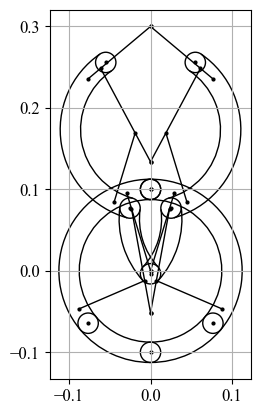

In [13]:
if __name__ == '__main__':
    file_name = 'plot_leg_example'
    
    plot_leg = PlotLeg()  # rad
    ax = plot_leg.plot_by_angle()
    ax = plot_leg.plot_by_angle(np.deg2rad(130), np.deg2rad(0), [0., 0.3], ax=ax)
    # ax = plot_leg.plot_by_rim([0.2, 0.0], [0.1, 0.3], rim='G', ax=ax)
    # ax = plot_leg.plot_by_rim([0.6, 0.1], [0.5, 0.2], rim='lower', ax=ax)
    # ax = plot_leg.plot_by_rim([0.3, 0.1], [0.4, 0.2], rim='lower', ax=ax)
    # plot_leg.setting(mark_size=10, line_width=3, color='red')
    # ax = plot_leg.plot_by_rim([0.8, 0.0], [0.9, 0.12], rim='upper', ax=ax)
    # ax = plot_leg.plot_by_rim([1.0, 0.0], [0.9, 0.12], rim='upper', ax=ax)
    ax.grid()
    
    plt.savefig(file_name + '.png')
    
    plt.show()
    plt.close()

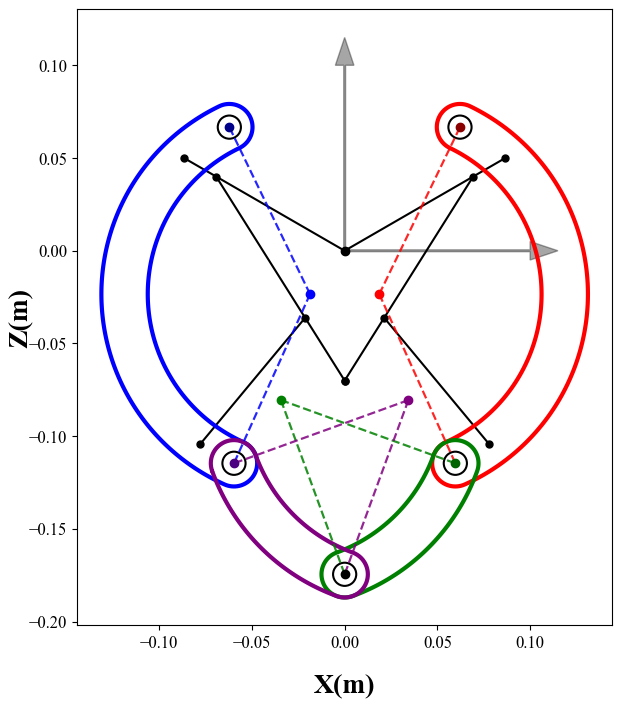

In [18]:
def plot_leg_with_key_points():
    # Set font to Times New Roman
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'font.size': 12,
        'mathtext.fontset': 'stix'  # This helps with math rendering in Times New Roman style
    })
    
    file_name = 'leg'
    plot_leg = PlotLeg()  # rad
    
    # Create a color dictionary for different parts
    arc_colors = {
        'upper_rim_r': 'red',
        'upper_rim_l': 'blue',
        'lower_rim_r': 'green',
        'lower_rim_l': 'purple',
        'joints': 'black',
        'bars': 'black'
    }
    
    # Set larger markers for better visibility of key points
    plot_leg.setting(mark_size=5, line_width=1.5)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot the leg with a specific angle
    theta = np.deg2rad(60)
    beta = np.deg2rad(0)
    O = np.array([0, 0])
    
    # Forward kinematics and shape generation
    plot_leg.forward(theta, beta, vector=False)
    plot_leg.leg_shape.get_shape(O)
    
    rim_zorder = 12
    guide_zorder = 13
    point_zorder = 14
    axis_zorder = 2
    
    def add_smooth_rim(ax, rim, color, zorder):
        center = np.asarray(rim.arc_fill.center)
        outer_radius = rim.arc_fill.r
        rim_width = rim.arc_fill.width
        inner_radius = outer_radius - rim_width
        mid_radius = 0.5 * (outer_radius + inner_radius)
        cap_radius = 0.5 * rim_width
        theta1 = np.deg2rad(rim.arc_fill.theta1)
        theta2 = np.deg2rad(rim.arc_fill.theta2)
        if theta2 < theta1:
            theta2 += 2 * np.pi
        theta = np.linspace(theta1, theta2, 160)
        outer = center + outer_radius * np.column_stack((np.cos(theta), np.sin(theta)))
        inner = center + inner_radius * np.column_stack((np.cos(theta[::-1]), np.sin(theta[::-1])))
        cap_end_center = center + mid_radius * np.array([np.cos(theta2), np.sin(theta2)])
        cap_start_center = center + mid_radius * np.array([np.cos(theta1), np.sin(theta1)])
        cap_end_theta = np.linspace(theta2, theta2 + np.pi, 40)
        cap_start_theta = np.linspace(theta1 + np.pi, theta1 + 2 * np.pi, 40)
        cap_end = cap_end_center + cap_radius * np.column_stack((np.cos(cap_end_theta), np.sin(cap_end_theta)))
        cap_start = cap_start_center + cap_radius * np.column_stack((np.cos(cap_start_theta), np.sin(cap_start_theta)))
        vertices = np.vstack((outer, cap_end, inner, cap_start, outer[:1]))
        codes = [Path.MOVETO] + [Path.LINETO] * (len(vertices) - 2) + [Path.CLOSEPOLY]
        patch = PathPatch(Path(vertices, codes), facecolor='none', edgecolor=color,
                          linewidth=3.0, capstyle='round', joinstyle='round', zorder=zorder)
        ax.add_patch(patch)
    
    # Add each leg part to the plot with custom colors
    for key, value in plot_leg.leg_shape.__dict__.items():
        if "rim" in key:
            rim_color = arc_colors.get(key, 'black')
            add_smooth_rim(ax, value, rim_color, rim_zorder)
        elif "joint" in key:
            value.set_edgecolor(arc_colors['joints'])
            value.set_linewidth(1.5)
            value.set_radius(value.get_radius() * 0.5)
            value.set_zorder(8)
            ax.add_patch(value)
        elif "bar" in key:
            value.set_color(arc_colors['bars'])
            value.set_linewidth(1.5)
            value.set_zorder(7)
            ax.add_line(value)
    
    # Add joint points with proper color
    plot_leg.joint_points = [ax.plot([], [], marker='o', color=arc_colors['joints'], 
                               markersize=5, zorder=point_zorder)[0] 
                           for _ in range(5)]
    
    for i, circle in enumerate([plot_leg.leg_shape.upper_joint_r, plot_leg.leg_shape.upper_joint_l, 
                               plot_leg.leg_shape.lower_joint_r, plot_leg.leg_shape.lower_joint_l, 
                               plot_leg.leg_shape.G_joint]):
        center = circle.get_center()
        plot_leg.joint_points[i].set_data([center[0]], [center[1]])
    
    # Add dashed lines connecting arc centers to joints
    arc_connections = [
        # Format: arc center, joint1, joint2, color
        (plot_leg.U_r, plot_leg.H_r, plot_leg.F_r, arc_colors['upper_rim_r']),
        (plot_leg.U_l, plot_leg.H_l, plot_leg.F_l, arc_colors['upper_rim_l']),
        (plot_leg.L_r, plot_leg.G, plot_leg.F_r, arc_colors['lower_rim_r']),
        (plot_leg.L_l, plot_leg.F_l, plot_leg.G, arc_colors['lower_rim_l'])
    ]
    
    for center, joint1, joint2, color in arc_connections:
        # Line from center to joint1
        ax.plot([center.real, joint1.real], [center.imag, joint1.imag], 
                linestyle='--', color=color, linewidth=1.6, alpha=0.85, zorder=guide_zorder)
        
        # Line from center to joint2
        ax.plot([center.real, joint2.real], [center.imag, joint2.imag], 
                linestyle='--', color=color, linewidth=1.6, alpha=0.85, zorder=guide_zorder)
    
    # Plot all the key points
    key_points = [
        ('H_r', [plot_leg.H_r.real, plot_leg.H_r.imag], 'darkred'),
        ('H_l', [plot_leg.H_l.real, plot_leg.H_l.imag], 'darkblue'),
        ('F_r', [plot_leg.F_r.real, plot_leg.F_r.imag], 'darkgreen'),
        ('F_l', [plot_leg.F_l.real, plot_leg.F_l.imag], 'indigo'),
        ('G', [plot_leg.G.real, plot_leg.G.imag], 'black'),
        ('U_r', [plot_leg.U_r.real, plot_leg.U_r.imag], 'red'),
        ('U_l', [plot_leg.U_l.real, plot_leg.U_l.imag], 'blue'),
        ('L_r', [plot_leg.L_r.real, plot_leg.L_r.imag], 'green'),
        ('L_l', [plot_leg.L_l.real, plot_leg.L_l.imag], 'purple'),
        ('O', [0, 0], 'black'),
    ]
    
    # Plot all key points and add labels
    for name, pos, color in key_points:
        ax.plot(pos[0], pos[1], 'o', markersize=6, color=color, zorder=point_zorder)
    
    # Add lighter coordinate axes
    arrow_length = 0.1
    arrow_width = 0.01
    axis_alpha = 0.35
    ax.arrow(0, 0, arrow_length, 0, head_width=arrow_width, head_length=arrow_width*1.5,
             fc='black', ec='black', alpha=axis_alpha, linewidth=1.0, zorder=axis_zorder)
    ax.arrow(0, 0, 0, arrow_length, head_width=arrow_width, head_length=arrow_width*1.5,
             fc='black', ec='black', alpha=axis_alpha, linewidth=1.0, zorder=axis_zorder)
    
    # Set grid and limits
    # ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_aspect('equal')
    ax.autoscale_view()
    
    # Put coordinate labels on the outer frame instead of beside the arrows.
    ax.text(0.5, -0.08, 'X(m)', transform=ax.transAxes, fontsize=20,
            fontfamily='Times New Roman', fontweight='bold', ha='center', va='top',
            clip_on=False, zorder=point_zorder)
    ax.text(-0.08, 0.5, 'Z(m)', transform=ax.transAxes, fontsize=20,
            fontfamily='Times New Roman', fontweight='bold', ha='right', va='center',
            rotation=90, clip_on=False, zorder=point_zorder)
    
    # Create a legend for the arc colors
    import matplotlib.patches as mpatches
    legend_elements = [
        mpatches.Patch(color=arc_colors['upper_rim_r'], label='Upper Rim Right'),
        mpatches.Patch(color=arc_colors['upper_rim_l'], label='Upper Rim Left'),
        mpatches.Patch(color=arc_colors['lower_rim_r'], label='Lower Rim Right'),
        mpatches.Patch(color=arc_colors['lower_rim_l'], label='Lower Rim Left')
    ]
    
    # Add the legend
    # ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9)
    
    # Save the figure with high resolution
    plt.savefig(file_name + '.png', dpi=1000, bbox_inches='tight')
    plt.show()
    
# Run the function to display the key points
plot_leg_with_key_points()


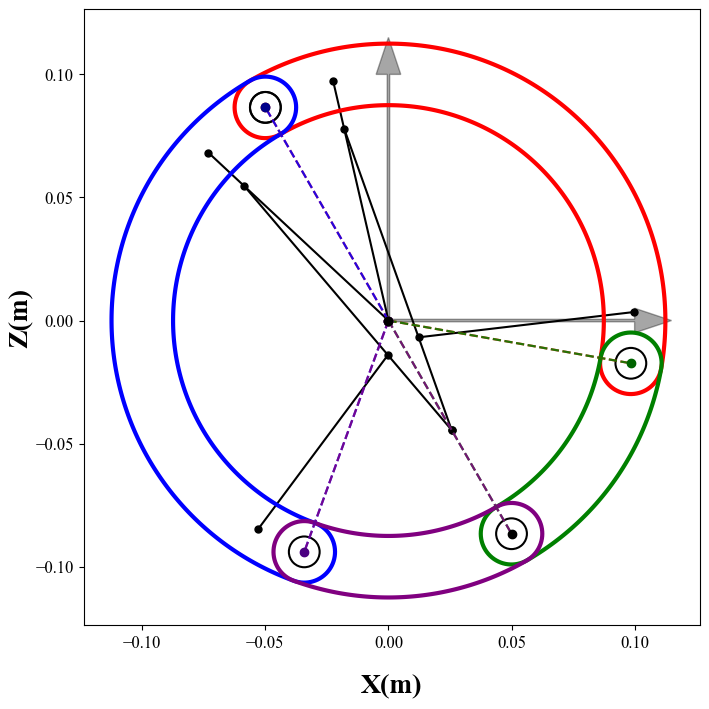

In [22]:
def plot_leg_with_key_points():
    # Set font to Times New Roman
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'font.size': 12,
        'mathtext.fontset': 'stix'  # This helps with math rendering in Times New Roman style
    })
    
    file_name = 'leg'
    plot_leg = PlotLeg()  # rad
    
    # Create a color dictionary for different parts
    arc_colors = {
        'upper_rim_r': 'red',
        'upper_rim_l': 'blue',
        'lower_rim_r': 'green',
        'lower_rim_l': 'purple',
        'joints': 'black',
        'bars': 'black'
    }
    
    # Set larger markers for better visibility of key points
    plot_leg.setting(mark_size=5, line_width=1.5)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot the leg with a specific angle
    theta = np.deg2rad(17)
    beta = np.deg2rad(30)
    O = np.array([0, 0])
    
    # Forward kinematics and shape generation
    plot_leg.forward(theta, beta, vector=False)
    plot_leg.leg_shape.get_shape(O)
    
    rim_zorder = 12
    guide_zorder = 13
    point_zorder = 14
    axis_zorder = 2
    
    def add_smooth_rim(ax, rim, color, zorder):
        center = np.asarray(rim.arc_fill.center)
        outer_radius = rim.arc_fill.r
        rim_width = rim.arc_fill.width
        inner_radius = outer_radius - rim_width
        mid_radius = 0.5 * (outer_radius + inner_radius)
        cap_radius = 0.5 * rim_width
        theta1 = np.deg2rad(rim.arc_fill.theta1)
        theta2 = np.deg2rad(rim.arc_fill.theta2)
        if theta2 < theta1:
            theta2 += 2 * np.pi
        theta = np.linspace(theta1, theta2, 160)
        outer = center + outer_radius * np.column_stack((np.cos(theta), np.sin(theta)))
        inner = center + inner_radius * np.column_stack((np.cos(theta[::-1]), np.sin(theta[::-1])))
        cap_end_center = center + mid_radius * np.array([np.cos(theta2), np.sin(theta2)])
        cap_start_center = center + mid_radius * np.array([np.cos(theta1), np.sin(theta1)])
        cap_end_theta = np.linspace(theta2, theta2 + np.pi, 40)
        cap_start_theta = np.linspace(theta1 + np.pi, theta1 + 2 * np.pi, 40)
        cap_end = cap_end_center + cap_radius * np.column_stack((np.cos(cap_end_theta), np.sin(cap_end_theta)))
        cap_start = cap_start_center + cap_radius * np.column_stack((np.cos(cap_start_theta), np.sin(cap_start_theta)))
        vertices = np.vstack((outer, cap_end, inner, cap_start, outer[:1]))
        codes = [Path.MOVETO] + [Path.LINETO] * (len(vertices) - 2) + [Path.CLOSEPOLY]
        patch = PathPatch(Path(vertices, codes), facecolor='none', edgecolor=color,
                          linewidth=3.0, capstyle='round', joinstyle='round', zorder=zorder)
        ax.add_patch(patch)
    
    # Add each leg part to the plot with custom colors
    for key, value in plot_leg.leg_shape.__dict__.items():
        if "rim" in key:
            rim_color = arc_colors.get(key, 'black')
            add_smooth_rim(ax, value, rim_color, rim_zorder)
        elif "joint" in key:
            value.set_edgecolor(arc_colors['joints'])
            value.set_linewidth(1.5)
            value.set_radius(value.get_radius() * 0.5)
            value.set_zorder(8)
            ax.add_patch(value)
        elif "bar" in key:
            value.set_color(arc_colors['bars'])
            value.set_linewidth(1.5)
            value.set_zorder(7)
            ax.add_line(value)
    
    # Add joint points with proper color
    plot_leg.joint_points = [ax.plot([], [], marker='o', color=arc_colors['joints'], 
                               markersize=5, zorder=point_zorder)[0] 
                           for _ in range(5)]
    
    for i, circle in enumerate([plot_leg.leg_shape.upper_joint_r, plot_leg.leg_shape.upper_joint_l, 
                               plot_leg.leg_shape.lower_joint_r, plot_leg.leg_shape.lower_joint_l, 
                               plot_leg.leg_shape.G_joint]):
        center = circle.get_center()
        plot_leg.joint_points[i].set_data([center[0]], [center[1]])
    
    # Add dashed lines connecting arc centers to joints
    arc_connections = [
        # Format: arc center, joint1, joint2, color
        (plot_leg.U_r, plot_leg.H_r, plot_leg.F_r, arc_colors['upper_rim_r']),
        (plot_leg.U_l, plot_leg.H_l, plot_leg.F_l, arc_colors['upper_rim_l']),
        (plot_leg.L_r, plot_leg.G, plot_leg.F_r, arc_colors['lower_rim_r']),
        (plot_leg.L_l, plot_leg.F_l, plot_leg.G, arc_colors['lower_rim_l'])
    ]
    
    for center, joint1, joint2, color in arc_connections:
        # Line from center to joint1
        ax.plot([center.real, joint1.real], [center.imag, joint1.imag], 
                linestyle='--', color=color, linewidth=1.6, alpha=0.85, zorder=guide_zorder)
        
        # Line from center to joint2
        ax.plot([center.real, joint2.real], [center.imag, joint2.imag], 
                linestyle='--', color=color, linewidth=1.6, alpha=0.85, zorder=guide_zorder)
    
    # Plot all the key points
    key_points = [
        ('H_r', [plot_leg.H_r.real, plot_leg.H_r.imag], 'darkred'),
        ('H_l', [plot_leg.H_l.real, plot_leg.H_l.imag], 'darkblue'),
        ('F_r', [plot_leg.F_r.real, plot_leg.F_r.imag], 'darkgreen'),
        ('F_l', [plot_leg.F_l.real, plot_leg.F_l.imag], 'indigo'),
        ('G', [plot_leg.G.real, plot_leg.G.imag], 'black'),
        ('U_r', [plot_leg.U_r.real, plot_leg.U_r.imag], 'red'),
        ('U_l', [plot_leg.U_l.real, plot_leg.U_l.imag], 'blue'),
        ('L_r', [plot_leg.L_r.real, plot_leg.L_r.imag], 'green'),
        ('L_l', [plot_leg.L_l.real, plot_leg.L_l.imag], 'purple'),
        ('O', [0, 0], 'black'),
    ]
    
    # Plot all key points and add labels
    for name, pos, color in key_points:
        ax.plot(pos[0], pos[1], 'o', markersize=6, color=color, zorder=point_zorder)
    
    # Add lighter coordinate axes
    arrow_length = 0.1
    arrow_width = 0.01
    axis_alpha = 0.35
    ax.arrow(0, 0, arrow_length, 0, head_width=arrow_width, head_length=arrow_width*1.5,
             fc='black', ec='black', alpha=axis_alpha, linewidth=1.0, zorder=axis_zorder)
    ax.arrow(0, 0, 0, arrow_length, head_width=arrow_width, head_length=arrow_width*1.5,
             fc='black', ec='black', alpha=axis_alpha, linewidth=1.0, zorder=axis_zorder)
    
    # Set grid and limits
    # ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_aspect('equal')
    ax.autoscale_view()
    
    # Put coordinate labels on the outer frame instead of beside the arrows.
    ax.text(0.5, -0.08, 'X(m)', transform=ax.transAxes, fontsize=20,
            fontfamily='Times New Roman', fontweight='bold', ha='center', va='top',
            clip_on=False, zorder=point_zorder)
    ax.text(-0.08, 0.5, 'Z(m)', transform=ax.transAxes, fontsize=20,
            fontfamily='Times New Roman', fontweight='bold', ha='right', va='center',
            rotation=90, clip_on=False, zorder=point_zorder)
    
    # Create a legend for the arc colors
    import matplotlib.patches as mpatches
    legend_elements = [
        mpatches.Patch(color=arc_colors['upper_rim_r'], label='Upper Rim Right'),
        mpatches.Patch(color=arc_colors['upper_rim_l'], label='Upper Rim Left'),
        mpatches.Patch(color=arc_colors['lower_rim_r'], label='Lower Rim Right'),
        mpatches.Patch(color=arc_colors['lower_rim_l'], label='Lower Rim Left')
    ]
    
    # Add the legend
    # ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9)
    
    # Save the figure with high resolution
    plt.savefig(file_name + '.png', dpi=1000, bbox_inches='tight')
    plt.show()
    
# Run the function to display the key points
plot_leg_with_key_points()


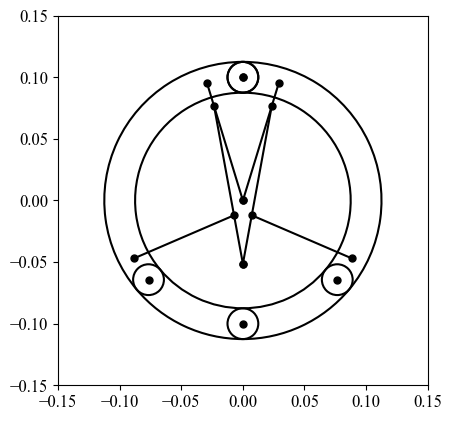

In [15]:
file_name = 'leg_alpha'

plot_leg = PlotLeg()  # rad
plot_leg.setting(mark_size=5, line_width=1.5)
ax = plot_leg.plot_by_angle(np.deg2rad(17), np.deg2rad(0))

ax.set_xlim(-0.15, 0.15)
ax.set_ylim(-0.15, 0.15)

# ax.grid()

plt.savefig(file_name + '.png', dpi=1000, bbox_inches='tight')

plt.show()